# PROJECT - Building a binary classification a model that takes a URL and predicts:
# Phishing (1) or Legitimate (0)

Phishing is a type of cyber attack where someone creates a fake website or message to trick you into giving:
Passwords
Credit card details
Personal information

It pretends to be a trusted source.

A legitimate website is a real, official, and trusted site created by the actual company or organization.
It:
Protects your data
Uses secure connections
Does NOT trick you

# LOADING DATASET 

SOURCE - KAGGLE 

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("phishingWebsiteDetection.csv")
df

,index,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,1,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,2,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,3,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,4,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,5,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11050,11051,1,-1,1,-1,1,1,1,1,-1,...,-1,-1,1,1,-1,-1,1,1,1,1
11051,11052,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,1,1,1,1,1,1,-1,1,-1
11052,11053,1,-1,1,1,1,-1,1,-1,-1,...,1,1,1,1,1,-1,1,0,1,-1
11053,11054,-1,-1,1,1,1,-1,-1,-1,1,...,-1,1,1,1,1,-1,1,1,1,-1


# DATA UNDERSTANDING

In [13]:
#no. of rows and columns
print(df.shape)

(11055, 32)


In [27]:
#checking missing values
print(df.isnull().sum())
#checking duplicate values
print("Duplicates:", df.duplicated().sum())

index                          0
having_IPhaving_IP_Address     0
URLURL_Length                  0
Shortining_Service             0
having_At_Symbol               0
double_slash_redirecting       0
Prefix_Suffix                  0
having_Sub_Domain              0
SSLfinal_State                 0
Domain_registeration_length    0
Favicon                        0
port                           0
HTTPS_token                    0
Request_URL                    0
URL_of_Anchor                  0
Links_in_tags                  0
SFH                            0
Submitting_to_email            0
Abnormal_URL                   0
Redirect                       0
on_mouseover                   0
RightClick                     0
popUpWidnow                    0
Iframe                         0
age_of_domain                  0
DNSRecord                      0
web_traffic                    0
Page_Rank                      0
Google_Index                   0
Links_pointing_to_page         0
Statistica

No missing or duplicate values in the dataset

# EDA

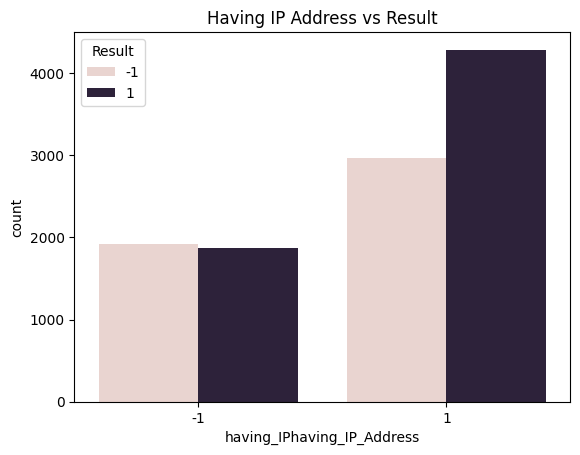

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='having_IPhaving_IP_Address', hue='Result', data=df)
plt.title("Having IP Address vs Result")
plt.show()

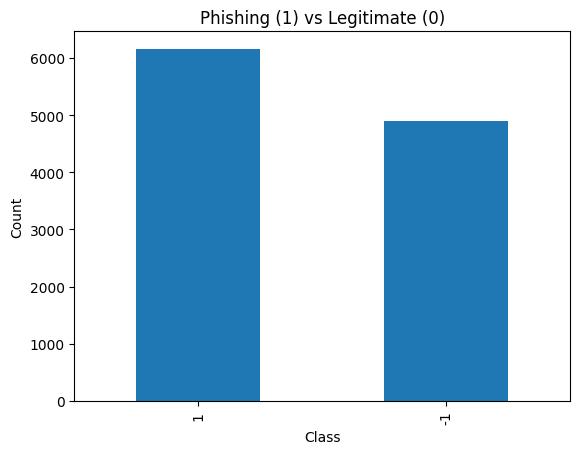

In [39]:
import matplotlib.pyplot as plt

df['Result'].value_counts()

df['Result'].value_counts().plot(kind='bar')
plt.title("Phishing (1) vs Legitimate (0)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

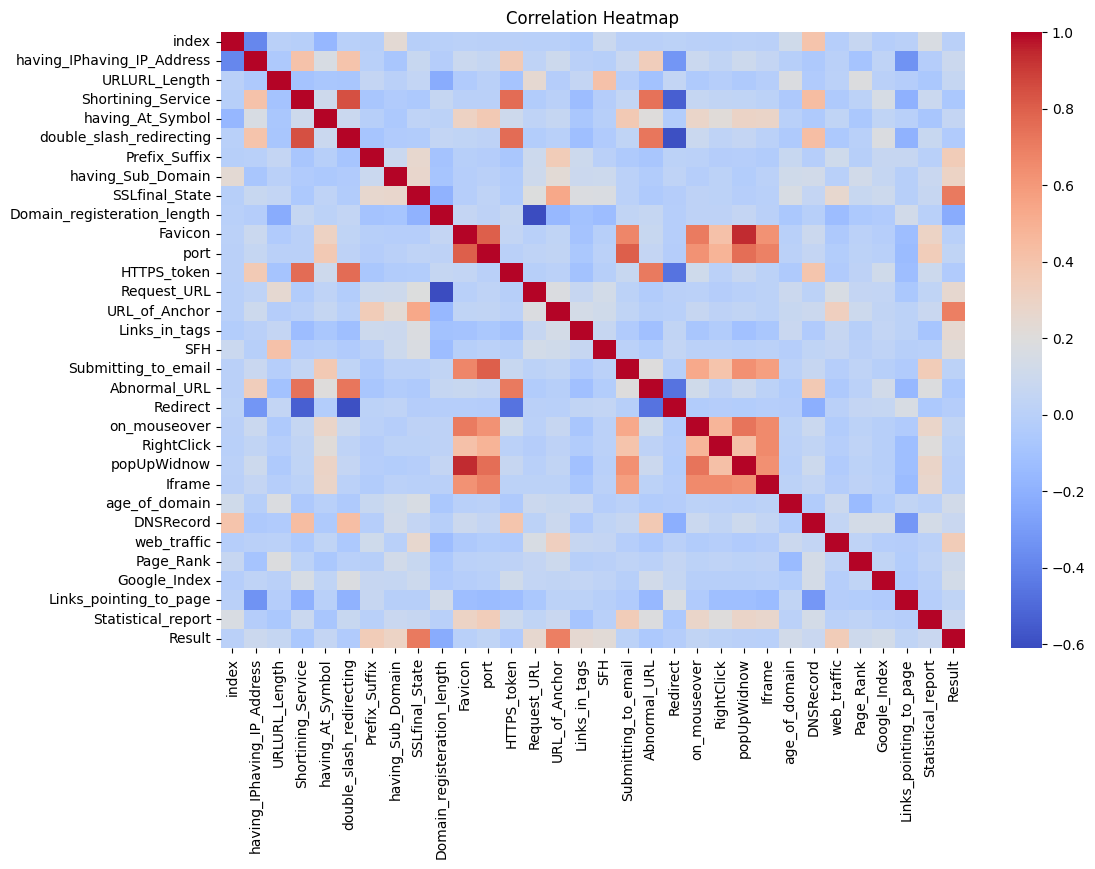

In [44]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# feature and target split

In [89]:
X = df.drop('Result', axis=1)
y = df['Result']

# train/test split

In [91]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# feature scaling

In [93]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Scaling was applied globally for simplicity, but it mainly benefits distance-based models like SVM and KNN, not tree-based models."

# defining multiple models

In [95]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [96]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier()
}

# Model training & Evaluation

In [98]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

In [115]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # for ROC-AUC
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results)
print(results_df)


                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.923112   0.927502  0.937849  0.932647
1        Random Forest  0.967436   0.963922  0.979283  0.971542
2    Gradient Boosting  0.947083   0.944531  0.963347  0.953846
3                  SVM  0.952510   0.947819  0.969721  0.958645
4                  KNN  0.945274   0.948576  0.955378  0.951965


# Visual performance of models

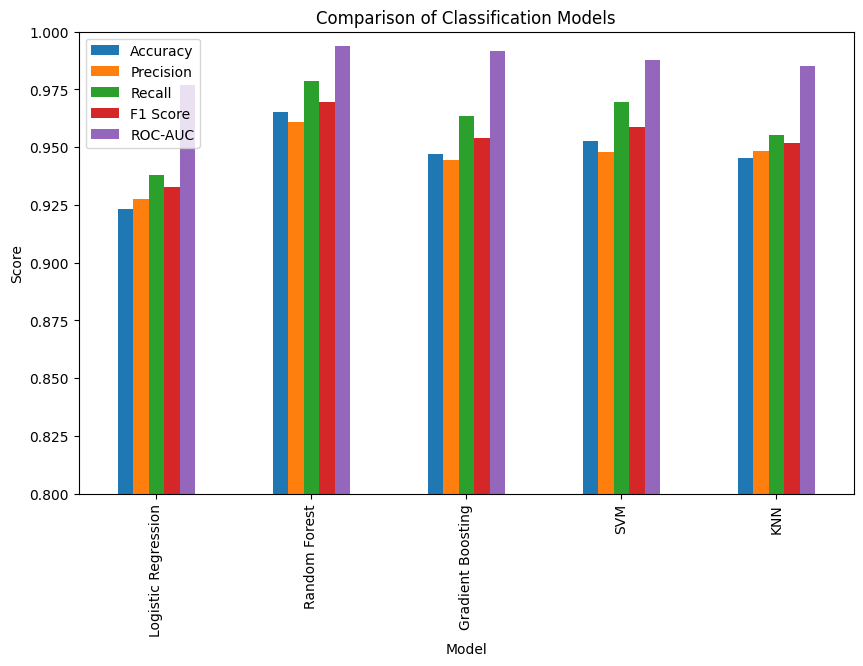

In [107]:
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]].plot(
    kind="bar", figsize=(10, 6)
)
plt.title("Comparison of Classification Models")
plt.ylabel("Score")
plt.ylim(0.8, 1.0)
plt.show()

# Confusion matrix

In [109]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 891   65]
 [  56 1199]]


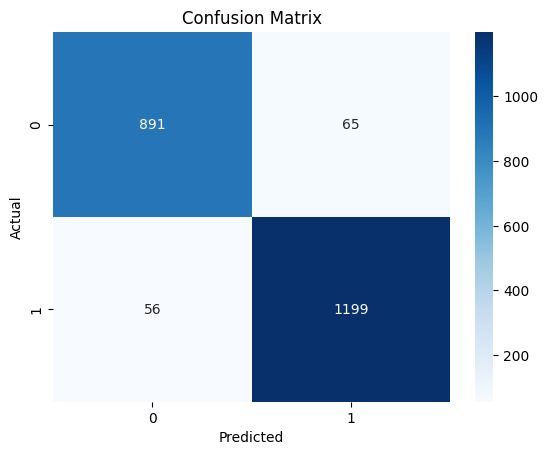

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# **CONCLUSION** - RANDOM FOREST PERFORMED THE BEST

Accuracy: 0.965 → highest
Precision: 0.9609 → highest
Recall: 0.9785 → highest
F1 Score: 0.9696 → highest
ROC-AUC: 0.9936 → highest